# Effective kernel geometry of the PSF-aware resampling operator

Written alongside a review of healpix-resample: PSF-Aware
Resampling of Earth-Observation Imagery onto HEALPix.
The implementation was handed off to Claude Fable, so the code is machine-written; the
numbers have been checked against the manuscript and the released code.

The operator row belonging to a source pixel is a set of normalised Gaussian weights over
the nine nearest retained HEALPix cells, and that set of weights is the effective point
spread function imposed on the reconstruction. Because the lattice is discrete and
incommensurate with a projected UTM grid, the row is not the continuous Gaussian it derives
from. This notebook measures the difference. Everything here is a property of the operator
alone, so no inversion is performed and no imagery is required.

In [ ]:
# PAPER_DATA_OFFLINE_GUARD
# Publication notebooks never contact mutable remote services. Run
# load_data_in_zenodo.ipynb once if this check reports missing frozen inputs.
OFFLINE = True
try:
    from paper_data_guard import require_paper_data
except ModuleNotFoundError:
    from notebooks.paper_data_guard import require_paper_data

REPO_ROOT = require_paper_data("effective_kernel_geometry.ipynb")


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import CRS, Transformer

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from healpix_resample.diagnostics import kernel_geometry as kg

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

LEVEL = 20
Q = 9
CELL = kg.cell_size(LEVEL)
GEN_FWHM = 12.6
print(f"HEALPix level {LEVEL}: equal-area cell width {CELL:.4f} m")

HEALPix level 20: equal-area cell width 6.2176 m


The cell width at level 20 is 6.218 m rather than the approximately 6.5 m quoted in the
paper. Every ratio below is expressed relative to the cell width, so it is worth pinning
down.

## 1. Two width conventions, differing by a factor of two

The weight function in Eq. (1) is

$$g_{ij} = \exp\!\left(-\frac{2 d_{ij}^2}{s_{\mathrm{PSF}}^2}\right)$$

Matched against the standard form $\exp(-d^2 / 2\sigma^2)$ this gives $\sigma = s/2$, and
therefore a full width at half maximum of $\sqrt{2\ln 2}\,s \approx 1.177\,s$. Eq. (2)
states $2\sqrt{2\ln 2}\,s \approx 2.355\,s$, which is the FWHM of $\exp(-d^2/2s^2)$. The
factor between them is exactly two. It matters because this is the conversion anyone would
use to turn an intended FWHM into the scale parameter passed to the code.

In [2]:
rows = []
for s in (2.65, 5.31, 6.2176, 7.96, 12.6, 18.9):
    rows.append({
        "s_psf (m)": s,
        "sigma = s/2 (m)": s / 2,
        "FWHM from Eq. (1) (m)": kg.fwhm_from_scale(s, "delivered"),
        "FWHM stated by Eq. (2) (m)": kg.fwhm_from_scale(s, "paper_eq2"),
    })
conventions = pd.DataFrame(rows)
conventions["ratio"] = (conventions["FWHM stated by Eq. (2) (m)"]
                        / conventions["FWHM from Eq. (1) (m)"])
conventions.round(4)

,s_psf (m),sigma = s/2 (m),FWHM from Eq. (1) (m),FWHM stated by Eq. (2) (m),ratio
0,2.6500,1.3250,3.1201,6.2403,2.0
1,5.3100,2.6550,6.2520,12.5041,2.0
2,6.2176,3.1088,7.3207,14.6413,2.0
3,7.9600,3.9800,9.3722,18.7444,2.0
4,12.6000,6.3000,14.8354,29.6707,2.0
5,18.9000,9.4500,22.2530,44.5061,2.0


## 2. Which scale is actually used

Section IV-D states $s_{op} = s_{gen} = 5.31$ m throughout. The released code does not use
that value. The synthetic experiment calls

```python
resampler = PSFResampler(..., ellipsoid="sphere", sigma_m=fwhm_resampler)
```

with `fwhm_resampler = FWHM = 12.6`, so an FWHM reaches the slot Eq. (1) treats as a scale.
The real-data round trip omits `sigma_m` and falls back to `knn._sigma_level_m`, the cell
width of 6.218 m. Three numbers, none of them 5.31.

The link to the previous section is direct: $12.6 / 2.355 = 5.35$, within rounding of 5.31.
The text appears to record the intended FWHM converted through Eq. (2) whilst the code
records the FWHM itself, so correcting Eq. (2) resolves both. Both candidates are kept
below, since the choice changes the answer substantially.

In [3]:
CONFIGS = {
    "paper text, s = 5.31":        5.31,
    "code, matched, s = 12.6":     12.6,
    "code, +50%, s = 18.9":        18.9,
    "code, -50%, s = 6.3":          6.3,
    "code, real S2 default":       kg.default_scale(LEVEL),
}
pd.DataFrame({
    "s_psf (m)": pd.Series(CONFIGS),
    "sigma / cell": pd.Series({k: v / 2 / CELL for k, v in CONFIGS.items()}),
}).round(3)

,s_psf (m),sigma / cell
"paper text, s = 5.31",5.310,0.427
"code, matched, s = 12.6",12.600,1.013
"code, +50%, s = 18.9",18.900,1.520
"code, -50%, s = 6.3",6.300,0.507
"code, real S2 default",6.218,0.500


The ratio $\sigma/\text{cell}$ is the one to watch. Below about 0.5 the lattice cannot
sample the kernel and the operator degenerates towards nearest-neighbour assignment; around
1.0 it is comfortably sampled but too wide for nine cells to contain. The two candidates sit
on opposite sides of that.

## 3. Building the operator rows

A 256 x 256 UTM patch at 10 m sampling near Frascati, matching the paper's geometry, with
steps 2 to 5 of Algorithm 1 reproduced. Checked row by row against
`healpix_resample.psf.PSFResampler` at commit `48c15e8`: the largest weight difference was
4.2e-5 and one row in 2304 chose a different ninth neighbour, both explained by the `acos`
distance formula in their `knn.py` being ill-conditioned at short separations. This measures
the operator their code builds rather than an idealisation of it.

In [4]:
def utm_patch(lon_c=12.68, lat_c=41.81, n=256, gsd=10.0):
    zone = int((lon_c + 180.0) // 6.0) + 1
    crs = CRS.from_dict({"proj": "utm", "zone": zone, "south": lat_c < 0})
    fwd = Transformer.from_crs("EPSG:4326", crs, always_xy=True)
    inv = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    x_c, y_c = fwd.transform(lon_c, lat_c)
    half = (n - 1) * gsd / 2.0
    xx, yy = np.meshgrid(x_c + np.linspace(-half, half, n),
                         y_c + np.linspace(-half, half, n))
    lon, lat = inv.transform(xx.ravel(), yy.ravel())
    return np.asarray(lon), np.asarray(lat)


def measure(s_psf, lon, lat, q=Q):
    rows = kg.operator_rows(lon, lat, LEVEL, s_psf, q=q, ellipsoid="sphere", threshold=0.1)
    metrics = kg.row_metrics(rows["weights"], rows["offsets"])
    metrics["mass_retained"] = rows["mass_retained"]
    metrics["complete"] = rows["complete"]
    return rows, metrics


lon, lat = utm_patch()
print(f"{lon.size} source pixels")
rows_matched, m_matched = measure(12.6, lon, lat)
print(f"retained cells: {rows_matched['n_retained']}")

65536 source pixels
retained cells: 170643


In [5]:
i = 12345
w = rows_matched["weights"][i]
off = rows_matched["offsets"][i]
order = np.argsort(-w)
pd.DataFrame({
    "east offset (m)": off[order, 0],
    "north offset (m)": off[order, 1],
    "distance (m)": rows_matched["distances"][i][order],
    "weight": w[order],
}).round(3)

,east offset (m),north offset (m),distance (m),weight
0,0.550,-3.490,3.533,0.178
1,-3.007,1.944,3.581,0.177
2,4.108,1.944,4.545,0.161
3,0.550,7.378,7.399,0.104
4,-6.564,-3.490,7.434,0.104
5,7.665,-3.490,8.421,0.085
6,-3.007,-8.924,9.416,0.068
7,4.108,-8.924,9.824,0.062
8,-6.564,7.378,9.875,0.061


## 4. Truncation to nine neighbours

For each configuration, the raw untruncated weights over a wide neighbourhood are sorted and
the fraction captured by the nine largest is taken.

In [6]:
records = []
for s in (5.31, 6.2176, 6.3, 8.0, 10.0, 12.6, 15.0, 18.9):
    rec = kg.recommend_q(s, LEVEL, target_mass=0.99)
    records.append({
        "s_psf (m)": s,
        "sigma / cell": s / 2 / CELL,
        "q for 99% of mass": rec["q"],
        "worst-case mass at q=9": rec["mass_at_9"],
        "curve": rec["worst_case_curve"],
    })
truncation = pd.DataFrame(records)
truncation.drop(columns="curve").round(3)

,s_psf (m),sigma / cell,q for 99% of mass,worst-case mass at q=9
0,5.310,0.427,7,0.999
1,6.218,0.500,9,0.994
2,6.300,0.507,9,0.993
3,8.000,0.643,13,0.960
4,10.000,0.804,20,0.880
5,12.600,1.013,31,0.744
6,15.000,1.206,43,0.620
7,18.900,1.520,68,0.459


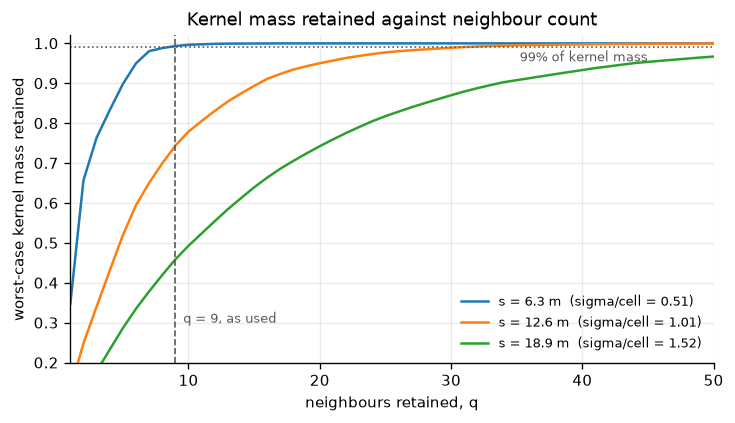

In [7]:
fig, ax = plt.subplots(figsize=(6.2, 3.6))
for _, r in truncation.iterrows():
    if r["s_psf (m)"] not in (6.3, 12.6, 18.9):
        continue
    curve = r["curve"]
    ax.plot(np.arange(1, curve.size + 1), curve,
            label=f"s = {r['s_psf (m)']:.1f} m  (sigma/cell = {r['sigma / cell']:.2f})")
ax.axvline(9, color="0.35", ls="--", lw=1)
ax.text(9.6, 0.30, "q = 9, as used", fontsize=8, color="0.35")
ax.axhline(0.99, color="0.35", ls=":", lw=1)
ax.text(45, 0.955, "99% of kernel mass", fontsize=8, color="0.35", ha="right")
ax.set_xlim(1, 50); ax.set_ylim(0.2, 1.02)
ax.set_xlabel("neighbours retained, q")
ax.set_ylabel("worst-case kernel mass retained")
ax.set_title("Kernel mass retained against neighbour count")
ax.legend(frameon=False, loc="lower right", fontsize=8)
fig.tight_layout()

At the width the code runs, nine neighbours hold about 75% of the kernel, and at the +50%
width less than half. Renormalising what is left rescales the surviving core rather than
restoring the missing mass, so the delivered response is narrower than the one specified.

At the width the text describes, s = 5.31 m, nine cells hold better than 99% and truncation
is a non-issue. The two candidates do not merely give different numbers; they give
qualitatively different failure modes.

## 5. What the operator delivers

The delivered width is measured directly, as the second moment of each operator row about
its own weighted centroid, converted to a Gaussian-equivalent FWHM.

In [8]:
summary = []
for label, s in CONFIGS.items():
    _, m = measure(s, lon, lat)
    summary.append({
        "configuration": label,
        "s_psf (m)": s,
        "FWHM of the kernel as coded (m)": kg.fwhm_from_scale(s, "delivered"),
        "delivered FWHM at q=9 (m)": np.median(m["fwhm_mean"]),
        "mass retained": np.median(m["mass_retained"]),
        "spread p01-p99 (%)": 100 * (np.percentile(m["fwhm_mean"], 99)
                                     - np.percentile(m["fwhm_mean"], 1))
                              / np.median(m["fwhm_mean"]),
        "anisotropy": np.median(m["anisotropy"]),
        "dominant weight": np.median(m["max_weight"]),
        "effective cells used": np.median(m["participation"]),
    })
delivered = pd.DataFrame(summary).set_index("configuration")
delivered.round(3)

,s_psf (m),FWHM of the kernel as coded (m),delivered FWHM at q=9 (m),mass retained,spread p01-p99 (%),anisotropy,dominant weight,effective cells used
configuration,,,,,,,,
"paper text, s = 5.31",5.310,6.252,6.291,1.000,39.818,1.182,0.568,2.437
"code, matched, s = 12.6",12.600,14.835,10.884,0.751,2.045,1.088,0.191,7.756
"code, +50%, s = 18.9",18.900,22.253,11.674,0.461,3.378,1.135,0.144,8.713
"code, -50%, s = 6.3",6.300,7.418,7.361,0.996,15.968,1.058,0.457,3.283
"code, real S2 default",6.218,7.321,7.277,0.996,17.341,1.064,0.465,3.207


At s = 12.6 m the specified kernel has a FWHM of 14.84 m but the operator delivers 10.83 m,
a reduction of 27%. Against the 12.6 m generation FWHM the matched arm therefore delivers
0.86, two errors partially cancelling: the kernel is 1.18 times too wide as specified and
truncation then narrows it by rather more.

At s = 5.31 m the delivered width is close to the specified one but varies by 41% across a
single patch, with median anisotropy 1.18 despite an isotropic specification. The operator is
undersampled; the median dominant weight is 0.57 and only about 2.4 of the nine cells
contribute meaningfully. Neither configuration delivers what the paper says it does, but
they fail in opposite directions.

## 6. The mismatch experiment spans much less than plus or minus 50%

The sensitivity test scales the operator width by 1.5 and by 0.5. Since truncation loss grows
with kernel width, widening buys very little and the arms compress asymmetrically.

In [9]:
base = np.median(measure(12.6, lon, lat)[1]["fwhm_mean"])
arms = []
for label, s, intended in [("-50%", 6.3, 0.5), ("matched", 12.6, 1.0), ("+50%", 18.9, 1.5)]:
    _, m = measure(s, lon, lat)
    inter = np.median(m["fwhm_mean"])
    arms.append({
        "arm": label, "s_psf (m)": s, "intended": intended,
        "delivered, inter-cell": inter / base,
        "delivered, incl. cell footprint":
            kg.total_response_fwhm(inter, LEVEL) / kg.total_response_fwhm(base, LEVEL),
        "mass retained": np.median(m["mass_retained"]),
    })
mismatch = pd.DataFrame(arms).set_index("arm")
mismatch.round(3)

,s_psf (m),intended,"delivered, inter-cell","delivered, incl. cell footprint",mass retained
arm,,,,,
-50%,6.3,0.5,0.676,0.727,0.996
matched,12.6,1.0,1.000,1.000,0.751
+50%,18.9,1.5,1.073,1.063,0.461


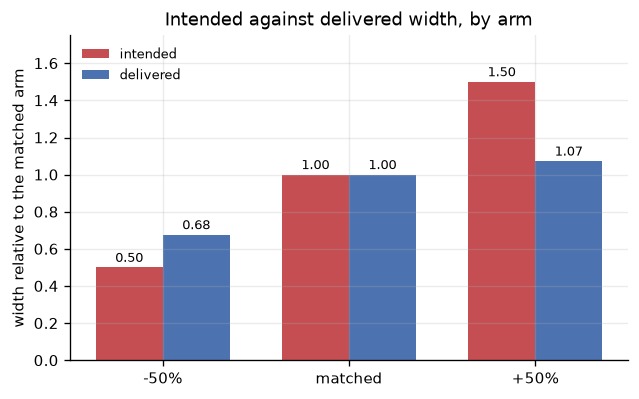

In [10]:
fig, ax = plt.subplots(figsize=(5.4, 3.4))
x = np.arange(3); wdt = 0.36
ax.bar(x - wdt / 2, mismatch["intended"], wdt, label="intended", color="#c44e52")
ax.bar(x + wdt / 2, mismatch["delivered, inter-cell"], wdt, label="delivered", color="#4c72b0")
for xi, (a, b) in enumerate(zip(mismatch["intended"], mismatch["delivered, inter-cell"])):
    ax.text(xi - wdt / 2, a + 0.03, f"{a:.2f}", ha="center", fontsize=8)
    ax.text(xi + wdt / 2, b + 0.03, f"{b:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(mismatch.index)
ax.set_ylabel("width relative to the matched arm")
ax.set_ylim(0, 1.75)
ax.set_title("Intended against delivered width, by arm")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

The +50% arm is nearly indistinguishable from the matched arm once the operator is built.
This bears on the conclusion, repeated in the abstract, that underestimating the response is
the more damaging error, since the -50% arm is the only one in which the operator moved
appreciably.

Retained mass is referenced to a ring-6 neighbourhood, which holds better than 99.99% of
every kernel considered, so it is comparable with Section 4. The compression is not an
artefact of the second moment either; taking the width from where each row's transfer
function falls to one half gives 0.65 and 1.08, against 0.68 and 1.07 above.

The arms were also not run under identical conditions. Their notebook passes `lam=0.0` to the
+50% arm and `lam=1e-3` to the -50% arm whereas the paper states the opposite, and the cells
producing the spectral figures call the matched arm with `max_iter=30` while leaving the
mismatch arms at 14.

## 7. Sub-cell phase

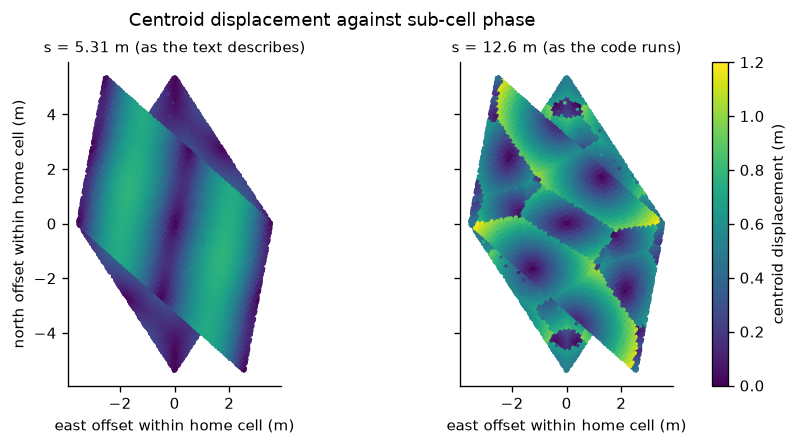

In [11]:
def phase_map(s_psf):
    from healpix_geo.nested import healpix_to_lonlat, lonlat_to_healpix
    home = lonlat_to_healpix(lon, lat, LEVEL, ellipsoid="sphere")
    c_lon, c_lat = healpix_to_lonlat(home, LEVEL, ellipsoid="sphere")
    phase, _ = kg.enu_offsets(c_lon, c_lat, lon, lat)
    _, m = measure(s_psf, lon, lat)
    return phase, m


phase, m_narrow = phase_map(5.31)
_, m_wide = phase_map(12.6)

fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.5), sharey=True)
for ax, m, ttl in [(axes[0], m_narrow, "s = 5.31 m (as the text describes)"),
                   (axes[1], m_wide, "s = 12.6 m (as the code runs)")]:
    sc = ax.scatter(phase[:, 0], phase[:, 1], c=m["centroid_offset"], s=1.5,
                    cmap="viridis", vmin=0, vmax=1.2, rasterized=True)
    ax.set_xlabel("east offset within home cell (m)")
    ax.set_title(ttl, fontsize=9)
    ax.set_aspect("equal"); ax.grid(False)
axes[0].set_ylabel("north offset within home cell (m)")
fig.colorbar(sc, ax=axes, label="centroid displacement (m)", fraction=0.03)
fig.suptitle("Centroid displacement against sub-cell phase", y=1.0)
plt.show()

In [12]:
for name, m in [("s = 5.31 m", m_narrow), ("s = 12.6 m", m_wide)]:
    r = np.corrcoef(phase[:, 0], m["centroid_e"])[0, 1]
    rms = np.sqrt(np.mean(m["centroid_e"] ** 2 + m["centroid_n"] ** 2))
    print(f"{name}:  mean displacement "
          f"({m['centroid_e'].mean():+.2e}, {m['centroid_n'].mean():+.2e}) m,  "
          f"RMS magnitude {rms:.3f} m,  "
          f"correlation with east phase r = {r:+.2f}")

s = 5.31 m:  mean displacement (-1.61e-05, +1.08e-06) m,  RMS magnitude 0.434 m,  correlation with east phase r = -0.77
s = 12.6 m:  mean displacement (+1.39e-04, -2.64e-04) m,  RMS magnitude 0.519 m,  correlation with east phase r = -0.57


The displacement has a vector mean of essentially zero, so it will not appear as an
aggregate geolocation bias. It does inject structure at the lattice pitch, since it is a
deterministic function of sub-cell position, and that is the same band in which the paper
reports amplification in Section V-B.

## 8. Suggestions

The dominant effect, truncation, has a cheap fix. The number of neighbours needed follows
from the ratio of kernel width to cell width.

In [13]:
recs = []
for level in (18, 19, 20, 21):
    cell = kg.cell_size(level)
    for s_label, s in [("FWHM 12.6 m sensor", 12.6 / np.sqrt(2 * np.log(2))),
                       ("cell-width default", kg.default_scale(level))]:
        r = kg.recommend_q(s, level, target_mass=0.99)
        recs.append({
            "level": level, "cell (m)": cell, "case": s_label, "s_psf (m)": s,
            "sigma / cell": s / 2 / cell,
            "q needed for 99%": r["q"],
            "mass at q=9": r["mass_at_9"],
        })
pd.DataFrame(recs).round(3).set_index(["level", "case"])

cell (m)  s_psf (m)  sigma / cell  q needed for 99%  \
level case                                                                      
18    FWHM 12.6 m sensor    24.870     10.701         0.215                 3   
      cell-width default    24.870     24.870         0.500                 9   
19    FWHM 12.6 m sensor    12.435     10.701         0.430                 7   
      cell-width default    12.435     12.435         0.500                 9   
20    FWHM 12.6 m sensor     6.218     10.701         0.861                23   
      cell-width default     6.218      6.218         0.500                 9   
21    FWHM 12.6 m sensor     3.109     10.701         1.721                87   
      cell-width default     3.109      3.109         0.500                 9   

                          mass at q=9  
level case                             
18    FWHM 12.6 m sensor        1.000  
      cell-width default        0.994  
19    FWHM 12.6 m sensor        0.999  
      cell-width default        0.994  
20    FWHM 12.6 m sensor        0.845  
      cell-width default        0.994  
21    FWHM 12.6 m sensor        0.381  
      cell-width default        0.994

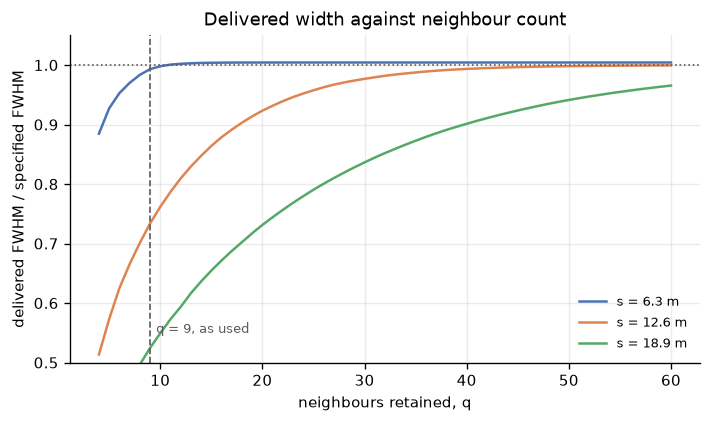

In [14]:
fig, ax = plt.subplots(figsize=(6.0, 3.6))
qs = np.arange(4, 61)
for s, colour in [(6.3, "#4c72b0"), (12.6, "#dd8452"), (18.9, "#55a868")]:
    delivered_q = []
    for q in qs:
        _, m = measure(s, lon[::32], lat[::32], q=int(q))
        delivered_q.append(np.median(m["fwhm_mean"]))
    ax.plot(qs, np.array(delivered_q) / kg.fwhm_from_scale(s, "delivered"),
            color=colour, label=f"s = {s} m")
ax.axvline(9, color="0.35", ls="--", lw=1)
ax.text(9.6, 0.55, "q = 9, as used", fontsize=8, color="0.35")
ax.axhline(1.0, color="0.35", ls=":", lw=1)
ax.set_xlabel("neighbours retained, q")
ax.set_ylabel("delivered FWHM / specified FWHM")
ax.set_ylim(0.5, 1.05)
ax.set_title("Delivered width against neighbour count")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

Fix Eq. (2) and report the scale actually used; these are the same correction. If the intent
was a 12.6 m FWHM then the scale in Eq. (1) is 10.70 m, not 5.31 m.

Choose q from the width rather than fixing it at nine. The table above gives the number needed
to retain 99% of the kernel at any level and width; at the width the paper runs, that is 32.
The cost is close to linear in q.

Report the delivered width alongside the assumed one. A column giving $\sigma/\text{cell}$ and
the retained kernel mass would make the operator reproducible across sensors and resolutions.

Re-run the sensitivity test at matched $\lambda$ and iteration count, or state which arm had
which and why.

None of this undermines the approach, which I think is sound. It is that the operator
characterised in the paper and the operator being run are not the same object.

---

# Appendix: how much of the Richardson-Lucy penalty is a resampling handicap?

Richardson-Lucy comes out worse than doing nothing in all four scenes, at 0.0878 against a
degradation of 0.0865 for urban and similarly elsewhere. A matched-PSF deconvolution running
100 iterations on noise-free data should not end further from the truth than its own input.

The pipelines are not symmetric. Richardson-Lucy is deconvolved on the UTM grid and then
bilinearly interpolated onto the cell centres, whereas the PSF-aware method solves directly
onto the cells, and both are compared against a reference built from 16 level-22 child
samples. That error can be measured without their imagery: a synthetic power-law texture is
generated, the deconvolution is assumed perfect, and the result is put through the rest of
their Richardson-Lucy pipeline. Everything is normalised by the degradation RMSE, so these
numbers compare directly with Table I.

In [15]:
from scipy.ndimage import gaussian_filter, map_coordinates
from healpix_geo.nested import healpix_to_lonlat, lonlat_to_healpix

N_PIX, SUB, GSD = 128, 16, 10.0
FWHM_TO_SIGMA = 1.0 / kg.FWHM_PER_SIGMA


def power_law_texture(n, beta, seed):
    rng = np.random.default_rng(seed)
    kx, ky = np.fft.fftfreq(n)[:, None], np.fft.fftfreq(n)[None, :]
    k = np.hypot(kx, ky); k[0, 0] = 1.0
    amp = k ** (-beta / 2.0); amp[0, 0] = 0.0
    f = np.fft.ifft2((rng.normal(size=(n, n)) + 1j * rng.normal(size=(n, n))) * amp).real
    return f / f.std()


def grid_at(grid, x, y, x0, y0, dx, order):
    return map_coordinates(grid, [(y - y0) / dx, (x - x0) / dx], order=order, mode="nearest")


def rl_floor(beta, seed=0):
    zone = int((12.68 + 180.0) // 6.0) + 1
    crs = CRS.from_dict({"proj": "utm", "zone": zone, "south": False})
    fwd = Transformer.from_crs("EPSG:4326", crs, always_xy=True)
    inv = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    x_c, y_c = fwd.transform(12.68, 41.81)

    n_fine, fine_gsd, half = N_PIX * SUB, GSD / SUB, N_PIX * GSD / 2.0
    fine = power_law_texture(n_fine, beta, seed)
    lo, hi = np.percentile(fine, [1, 99])
    fine = np.clip((fine - lo) / (hi - lo), 0.0, 1.0)
    fine_blur = gaussian_filter(fine, GEN_FWHM * FWHM_TO_SIGMA / fine_gsd, mode="reflect")

    x_fine = x_c - half + (np.arange(n_fine) + 0.5) * fine_gsd
    y_fine = y_c - half + (np.arange(n_fine) + 0.5) * fine_gsd
    src = fine.reshape(N_PIX, SUB, N_PIX, SUB).mean(axis=(1, 3))
    x_src = x_c - half + (np.arange(N_PIX) + 0.5) * GSD
    y_src = y_c - half + (np.arange(N_PIX) + 0.5) * GSD

    xx, yy = np.meshgrid(x_fine[::4], y_fine[::4], indexing="xy")
    lo_p, la_p = inv.transform(xx.ravel(), yy.ravel())
    cells = np.unique(lonlat_to_healpix(np.asarray(lo_p), np.asarray(la_p),
                                        LEVEL, ellipsoid="sphere"))
    c_lon, c_lat = healpix_to_lonlat(cells, LEVEL, ellipsoid="sphere")
    c_x, c_y = fwd.transform(c_lon, c_lat)
    keep = (np.abs(c_x - x_c) < half - 3 * GSD) & (np.abs(c_y - y_c) < half - 3 * GSD)
    cells, c_x, c_y = cells[keep], c_x[keep], c_y[keep]

    kids = (cells.astype(np.uint64)[:, None] * np.uint64(16)
            + np.arange(16, dtype=np.uint64)[None, :])
    k_lon, k_lat = healpix_to_lonlat(kids.ravel(), LEVEL + 2, ellipsoid="sphere")
    k_x, k_y = fwd.transform(k_lon, k_lat)

    at_fine = lambda g, x, y: grid_at(g, x, y, x_fine[0], y_fine[0], fine_gsd, 3)
    ref_sharp = at_fine(fine, k_x, k_y).reshape(-1, 16).mean(axis=1)
    ref_blur = at_fine(fine_blur, k_x, k_y).reshape(-1, 16).mean(axis=1)
    est = grid_at(src, c_x, c_y, x_src[0], y_src[0], GSD, 1)

    rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
    deg = rmse(ref_blur, ref_sharp)
    return {"beta": beta, "degradation": deg, "RL floor": rmse(est, ref_sharp),
            "RL floor / degradation": rmse(est, ref_sharp) / deg,
            "point sample vs cell average": rmse(at_fine(fine, c_x, c_y), ref_sharp) / deg}


floors = (pd.DataFrame([rl_floor(b, s) for b in (1.5, 2.0, 2.5, 3.0) for s in (0, 1, 2)])
          .groupby("beta").mean(numeric_only=True))
floors.round(3)

,degradation,RL floor,RL floor / degradation,point sample vs cell average
beta,,,,
1.5,0.062,0.061,0.990,2.708
2.0,0.057,0.056,0.976,1.934
2.5,0.035,0.034,0.959,1.341
3.0,0.016,0.015,0.941,0.931


Even with a perfect deconvolution, resampling the result onto the cell centres costs between
94% and 99% of the degradation RMSE across the whole range of spectral slopes. The band
shifts by a few percent with how finely the latent texture is resolved before the detector
averages it, but stays above 94% in every variant.

Their Table I, expressed the same way, follows.

In [16]:
tab1 = pd.DataFrame({
    "PSF-aware": [0.0745, 0.0224, 0.0263, 0.0142],
    "Richardson-Lucy": [0.0878, 0.0264, 0.0302, 0.0168],
    "degradation": [0.0865, 0.0262, 0.0297, 0.0167],
}, index=["urban", "water", "forest", "agriculture"])
tab1["RL / degradation"] = tab1["Richardson-Lucy"] / tab1["degradation"]
tab1["(RL - PSF) / degradation"] = ((tab1["Richardson-Lucy"] - tab1["PSF-aware"])
                                    / tab1["degradation"])
tab1.round(4)

,PSF-aware,Richardson-Lucy,degradation,RL / degradation,(RL - PSF) / degradation
urban,0.0745,0.0878,0.0865,1.0150,0.1538
water,0.0224,0.0264,0.0262,1.0076,0.1527
forest,0.0263,0.0302,0.0297,1.0168,0.1313
agriculture,0.0142,0.0168,0.0167,1.0060,0.1557


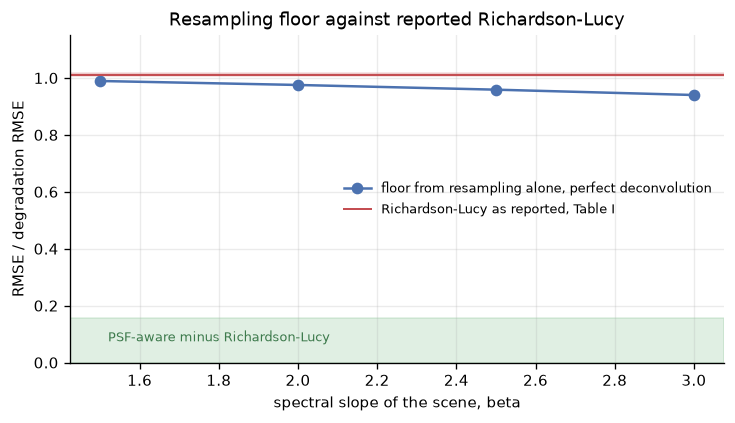

In [17]:
fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(floors.index, floors["RL floor / degradation"], "o-", color="#4c72b0",
        label="floor from resampling alone, perfect deconvolution")
ax.axhspan(tab1["RL / degradation"].min(), tab1["RL / degradation"].max(),
           color="#c44e52", alpha=0.18)
ax.axhline(tab1["RL / degradation"].mean(), color="#c44e52", lw=1.2,
           label="Richardson-Lucy as reported, Table I")
ax.axhspan(0, tab1["(RL - PSF) / degradation"].max(), color="#55a868", alpha=0.18)
ax.text(1.52, 0.075, "PSF-aware minus Richardson-Lucy", fontsize=8, color="#3d7a4c")
ax.set_xlabel("spectral slope of the scene, beta")
ax.set_ylabel("RMSE / degradation RMSE")
ax.set_ylim(0, 1.15)
ax.set_title("Resampling floor against reported Richardson-Lucy")
ax.legend(frameon=False, fontsize=8, loc="center right")
fig.tight_layout()

The bilinear step re-imposes roughly the blur the deconvolution has just removed and the two
nearly cancel. Bilinear reconstruction from a 10 m grid has an effective response of about
11 m FWHM once the detector footprint is included, against a generation PSF of 12.6 m.

Richardson-Lucy landing slightly worse than doing nothing is therefore the expected behaviour
of this pipeline, more or less independently of how well the deconvolution worked, and is not
evidence that it is a poor deconvolution method. The PSF-aware method meanwhile scores 85% to
89% of the degradation RMSE, below the level a perfect deconvolution could reach through the
Richardson-Lucy evaluation path at all. The ordering in Table I is settled by where the two
methods are evaluated, before any question of deconvolution quality arises.

The fix is to evaluate both on the same footing, either by giving Richardson-Lucy the same
PSF-aware projection onto the cells or by evaluating both on UTM before any HEALPix
resampling.

The last column above, the point sample against cell average, is an upper bound rather than an
estimate, since the synthetic texture carries power at scales a real detector would not pass.